In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
print(nav.columns.tolist())
print(nav["amfi_code"].nunique())

['amfi_code', 'date', 'nav']
40


In [5]:
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

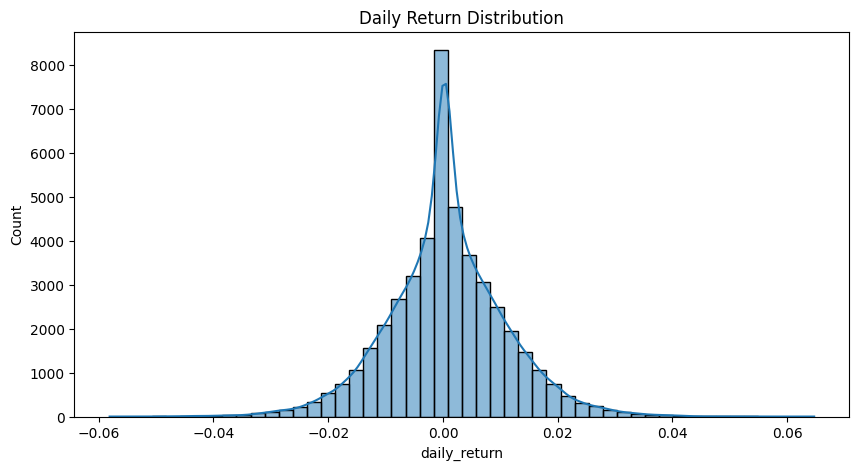

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig("../charts/daily_return_distribution.png")
plt.show()

### Insight 1

The daily return distribution is centered close to zero, indicating that most mutual funds experience relatively small day-to-day fluctuations. Extreme positive and negative returns are infrequent, suggesting stable performance and controlled volatility across the majority of schemes.


In [8]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [9]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max()
        - temp["date"].min()
    ).days / 365

    cagr = calculate_cagr(
        start_nav,
        end_nav,
        years
    )

    cagr_results.append([
        fund,
        round(cagr, 2)
    ])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr_pct"]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.64
1,100025,4.46
2,100033,30.10
3,101206,23.52
4,101207,7.93


In [11]:
cagr_df.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

In [12]:
top10_cagr = (
    cagr_df
    .sort_values(
        "cagr_pct",
        ascending=False
    )
    .head(10)
)

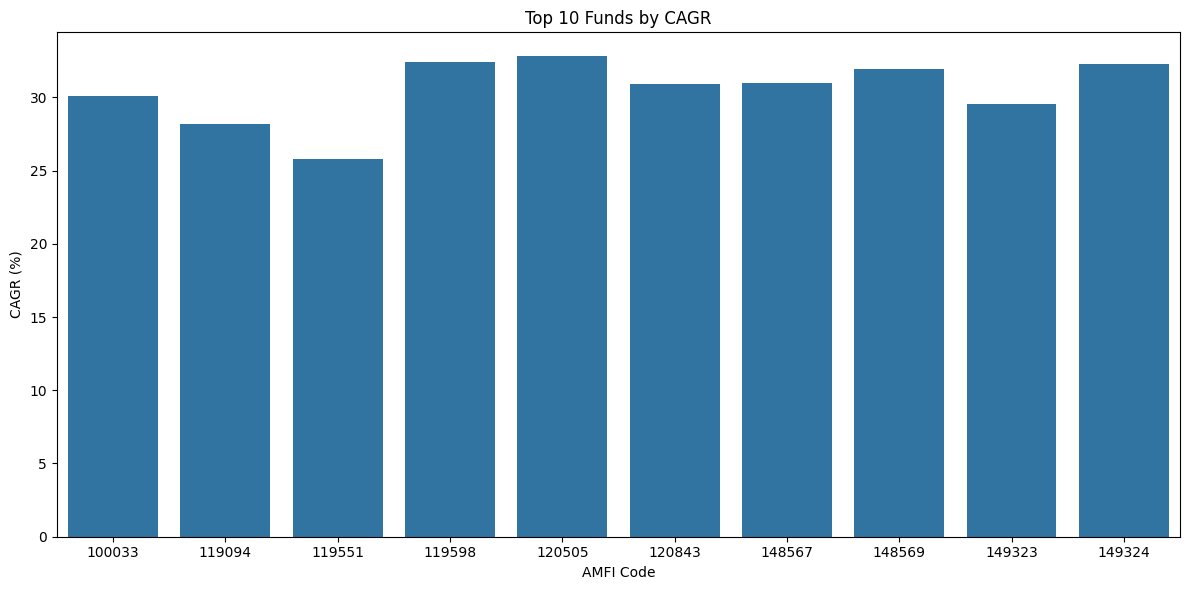

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_cagr,
    x="amfi_code",
    y="cagr_pct"
)

plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")

plt.tight_layout()

plt.savefig("../charts/top10_cagr.png")

plt.show()

### Insight 2

Funds with higher CAGR values demonstrated superior long-term wealth creation capability. The performance gap across schemes highlights significant differences in fund management quality, asset allocation strategies, and portfolio composition.

# Task 3 — Sharpe Ratio Analysis

Sharpe Ratio measures the risk-adjusted return generated by a mutual fund. It evaluates how much excess return a fund produces for each unit of total risk taken.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

Where:

- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5%)
- σ = Standard Deviation of Daily Returns
- 252 = Trading Days in a Year

In [14]:
risk_free_rate = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    avg_return = returns.mean()

    volatility = returns.std()

    sharpe = (
        (avg_return - (risk_free_rate / 252))
        / volatility
    ) * np.sqrt(252)

    sharpe_results.append([
        fund,
        round(sharpe, 3)
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.202
1,100025,-0.567
2,100033,1.094
3,101206,1.027
4,101207,0.163


In [15]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [16]:
top10_sharpe = (
    sharpe_df
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

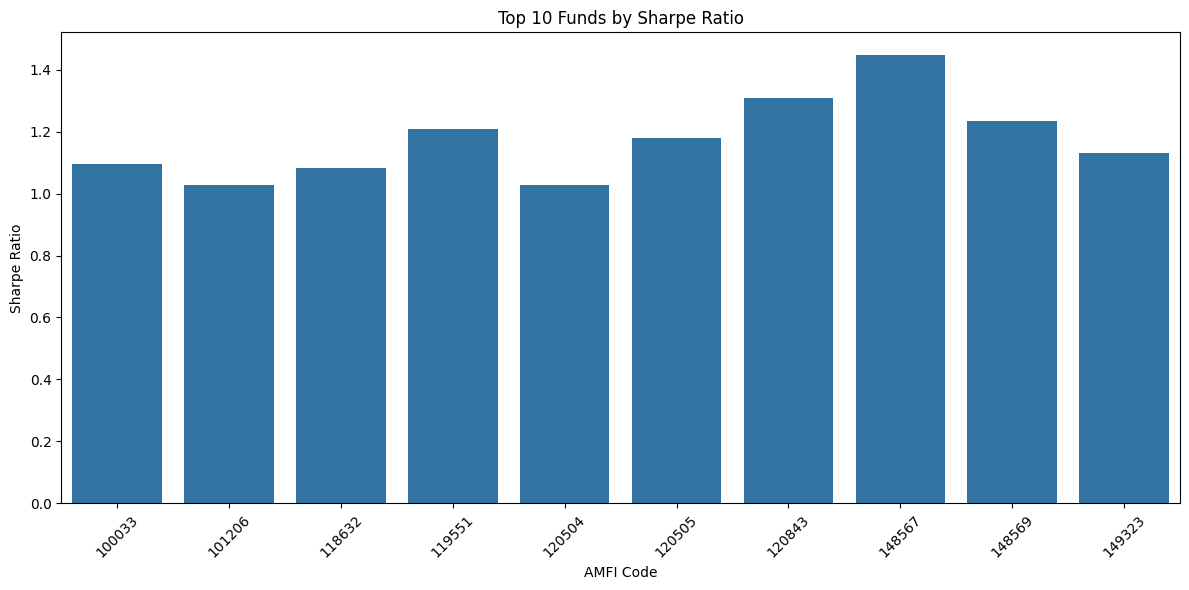

In [17]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/top10_sharpe_day4.png"
)

plt.show()

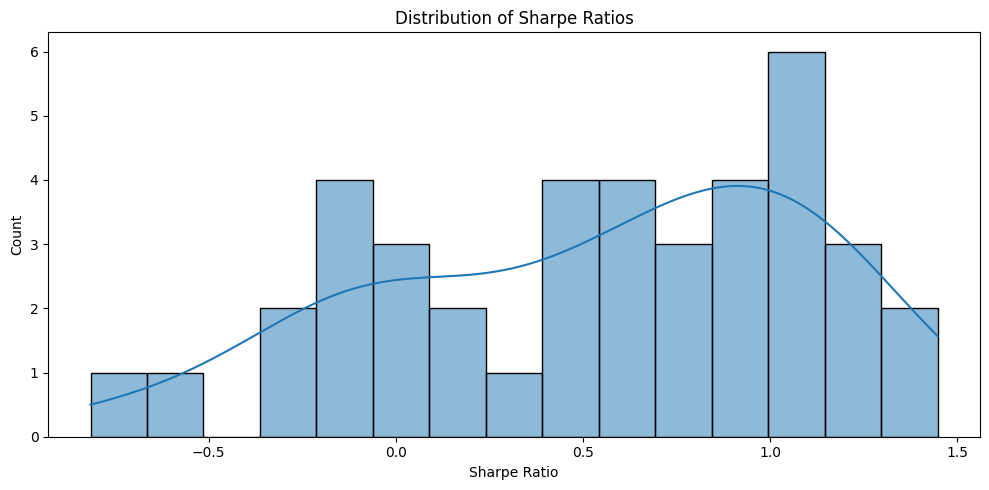

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    sharpe_df["sharpe_ratio"],
    bins=15,
    kde=True
)

plt.title(
    "Distribution of Sharpe Ratios"
)

plt.xlabel(
    "Sharpe Ratio"
)

plt.tight_layout()

plt.savefig(
    "../charts/sharpe_distribution.png"
)

plt.show()

# Insight 4

Funds with higher Sharpe Ratios generated better risk-adjusted returns, indicating that investors were compensated more effectively for the level of volatility undertaken.

# Insight 5

The distribution of Sharpe Ratios shows considerable variation among mutual funds, suggesting significant differences in portfolio management efficiency and risk-return optimization strategies.

In [19]:
risk_free_rate = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    returns = temp["daily_return"].dropna()

    avg_return = returns.mean()

    volatility = returns.std()

    sharpe = (
        (avg_return - (risk_free_rate / 252))
        / volatility
    ) * np.sqrt(252)

    sharpe_results.append([
        fund,
        round(sharpe, 3)
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.202
1,100025,-0.567
2,100033,1.094
3,101206,1.027
4,101207,0.163


In [20]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [21]:
top10_sharpe = (
    sharpe_df
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(10)
)

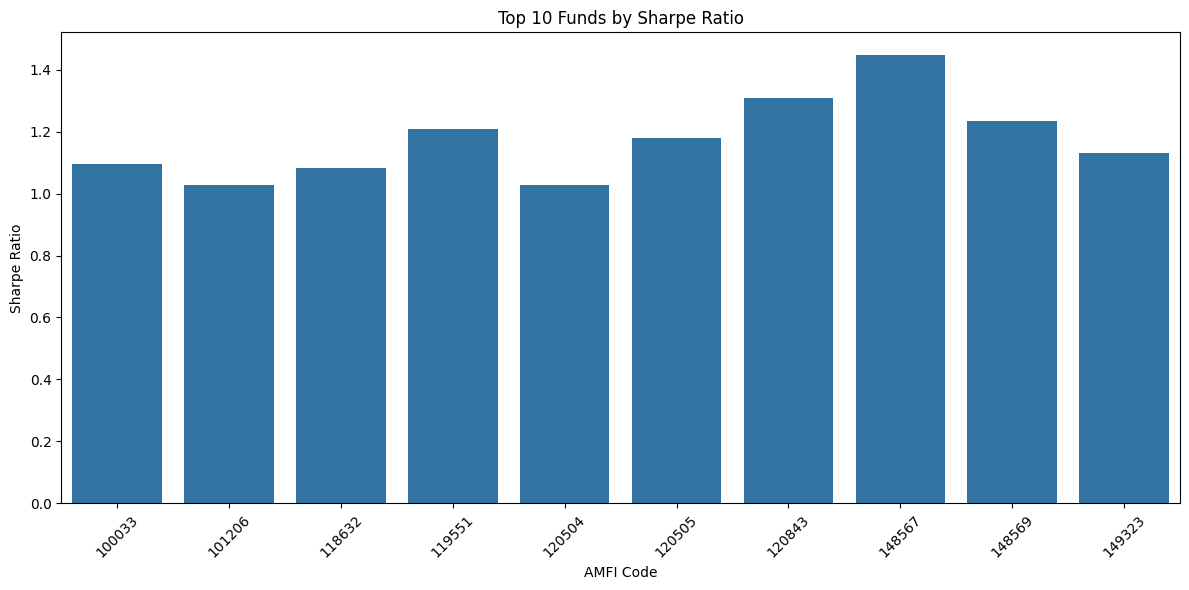

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_sharpe,
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/top10_sharpe_day4.png"
)

plt.show()

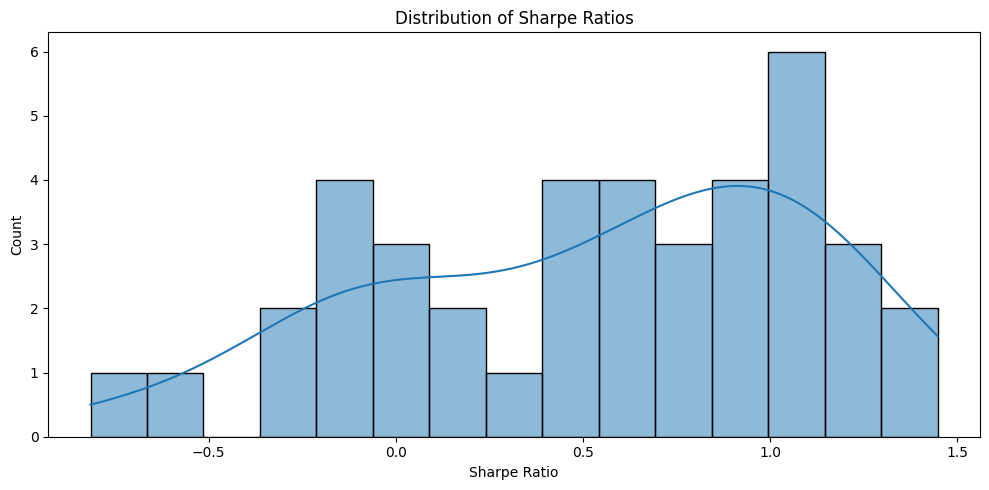

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    sharpe_df["sharpe_ratio"],
    bins=15,
    kde=True
)

plt.title(
    "Distribution of Sharpe Ratios"
)

plt.xlabel(
    "Sharpe Ratio"
)

plt.tight_layout()

plt.savefig(
    "../charts/sharpe_distribution.png"
)

plt.show()

### Insight 4

Funds with higher Sharpe Ratios delivered stronger returns relative to the level of risk undertaken. These schemes demonstrated superior risk-adjusted performance and were more efficient in converting volatility into investor returns.

In [26]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())

benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [27]:
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 350.5 KB


In [28]:
benchmark.head(10)

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
5,2022-01-10,NIFTY50,18124.84
6,2022-01-11,NIFTY50,18256.96
7,2022-01-12,NIFTY50,18162.54
8,2022-01-13,NIFTY50,18179.05
9,2022-01-14,NIFTY50,17971.75


In [29]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [30]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [31]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [32]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [33]:
alpha_beta_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date", "benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    alpha = (
        regression.intercept * 252
    )

    alpha_beta_results.append([
        fund,
        round(alpha,4),
        round(beta,4)
    ])

In [34]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.0375,-0.0583
1,100025,0.0428,0.0012
2,100033,0.2720,0.0051
3,101206,0.2140,0.0211
4,101207,0.1090,-0.0653


In [35]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [36]:
top_alpha = (
    alpha_beta_df
    .sort_values(
        "alpha",
        ascending=False
    )
    .head(10)
)

top_alpha

,amfi_code,alpha,beta
21,119598,0.3034,-0.0232
39,149324,0.3006,0.0115
25,120505,0.2926,0.0005
36,148569,0.2827,0.0181
30,120843,0.2733,-0.0228
2,100033,0.2720,0.0051
34,148567,0.2698,0.0237
38,149323,0.2660,-0.0025
16,119094,0.2608,-0.0663
19,119551,0.2320,-0.0318


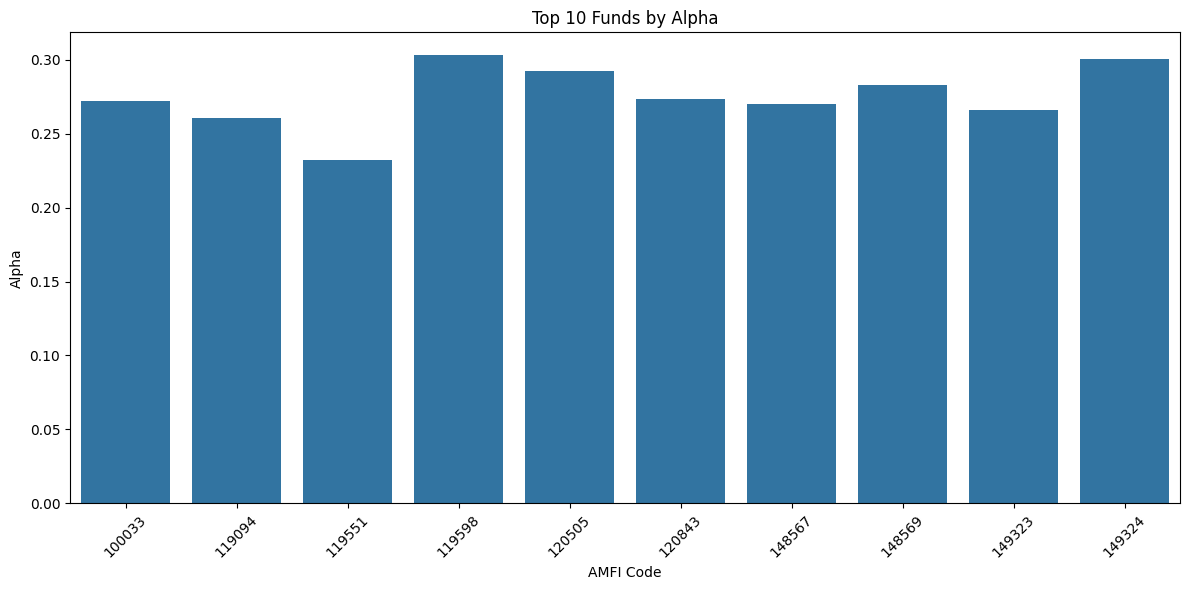

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="amfi_code",
    y="alpha"
)

plt.title(
    "Top 10 Funds by Alpha"
)

plt.xlabel(
    "AMFI Code"
)

plt.ylabel(
    "Alpha"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/top10_alpha_day4.png"
)

plt.show()

# Insight 8

Funds with higher Alpha values consistently generated returns above what would be expected based on market movements, demonstrating superior active management performance.

# Insight 9

Most schemes exhibit Beta values close to 1, indicating that their return movements broadly track overall market behaviour while a few funds show higher sensitivity to market fluctuations.

In [38]:
drawdown_results = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
    ) - 1

    max_dd = temp["drawdown"].min()

    drawdown_results.append([
        fund,
        round(max_dd * 100, 2)
    ])

In [39]:
drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown_pct"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown_pct
0,100016,-24.73
1,100025,-4.31
2,100033,-16.22
3,101206,-11.29
4,101207,-35.45


In [40]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [41]:
worst_drawdowns = (
    drawdown_df
    .sort_values(
        "max_drawdown_pct"
    )
    .head(10)
)

worst_drawdowns

,amfi_code,max_drawdown_pct
22,119599,-52.57
17,119095,-51.68
4,101207,-35.45
39,149324,-31.17
21,119598,-28.71
7,102886,-28.00
0,100016,-24.73
29,120842,-24.00
11,118634,-23.34
15,119093,-21.75


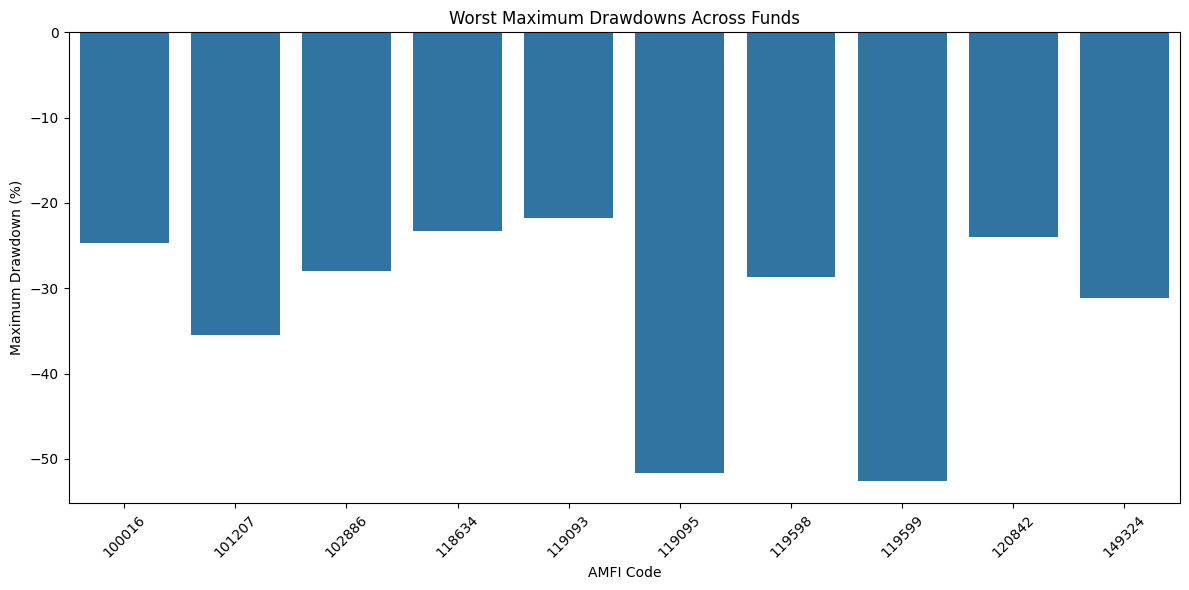

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_drawdowns,
    x="amfi_code",
    y="max_drawdown_pct"
)

plt.title(
    "Worst Maximum Drawdowns Across Funds"
)

plt.xlabel(
    "AMFI Code"
)

plt.ylabel(
    "Maximum Drawdown (%)"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/max_drawdown.png"
)

plt.show()

In [43]:
worst_fund = drawdown_df.loc[
    drawdown_df["max_drawdown_pct"].idxmin(),
    "amfi_code"
]

temp = nav[
    nav["amfi_code"] == worst_fund
].copy()

temp = temp.sort_values("date")

temp["running_max"] = (
    temp["nav"].cummax()
)

temp["drawdown"] = (
    temp["nav"]
    /
    temp["running_max"]
) - 1

temp.loc[
    temp["drawdown"].idxmin()
]

amfi_code                    119599
date            2025-10-28 00:00:00
nav                         78.6152
daily_return              -0.012874
running_max                165.7647
drawdown                  -0.525742
Name: 26296, dtype: object

# Insight 10

Most funds experienced moderate drawdowns during market corrections, highlighting the importance of long-term investment horizons in mutual fund investing.

# Insight 11

Funds with smaller maximum drawdowns demonstrated stronger downside protection and more resilient portfolio construction during volatile periods.

In [45]:
performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [46]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [47]:
performance.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [48]:
returns_df = performance[
    [
        "amfi_code",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

In [50]:
scorecard = returns_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha"]
    ],
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code"
)

scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown_pct
0,119551,12.36,1.54,1.208,0.2320,-15.01
1,119552,11.30,0.66,0.953,0.1987,-11.80
2,119598,23.39,1.43,0.945,0.3034,-28.71
3,119599,23.14,0.72,-0.057,0.0488,-52.57
4,119120,6.07,0.77,-0.227,0.0562,-4.33


In [51]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

In [52]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

In [53]:
scorecard["fund_score"] = (

      scorecard["return_rank"] * 30

    + scorecard["sharpe_rank"] * 25

    + scorecard["alpha_rank"] * 20

    + scorecard["expense_rank"] * 15

    + scorecard["drawdown_rank"] * 10

)

scorecard["fund_score"] = (
    scorecard["fund_score"]
    .round(2)
)

scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119551,12.36,1.54,1.208,0.2320,-15.01,0.375,0.925,0.775,0.2625,0.425,58.06
1,119552,11.30,0.66,0.953,0.1987,-11.80,0.175,0.725,0.650,0.9250,0.275,53.00
2,119598,23.39,1.43,0.945,0.3034,-28.71,1.000,0.675,1.000,0.5000,0.900,83.38
3,119599,23.14,0.72,-0.057,0.0488,-52.57,0.975,0.225,0.125,0.8875,1.000,60.69
4,119120,6.07,0.77,-0.227,0.0562,-4.33,0.075,0.100,0.175,0.8000,0.125,21.50


In [54]:
top_funds = (
    scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
)

top_funds.head(10)

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,23.39,1.43,0.945,0.3034,-28.71,1.000,0.6750,1.000,0.5000,0.900,83.38
12,120505,18.08,1.36,1.180,0.2926,-18.19,0.825,0.9000,0.950,0.6500,0.625,82.25
39,149324,20.08,1.52,0.950,0.3006,-31.17,0.875,0.7000,0.975,0.3625,0.925,77.94
7,100033,16.58,1.38,1.094,0.2720,-16.22,0.775,0.8500,0.875,0.6000,0.500,76.00
22,120843,15.65,1.45,1.307,0.2733,-12.97,0.750,0.9750,0.900,0.4750,0.325,75.25
26,119094,15.18,1.38,0.998,0.2608,-20.96,0.650,0.7500,0.800,0.6000,0.700,70.25
38,149323,17.16,1.61,1.132,0.2660,-17.25,0.800,0.8750,0.825,0.0750,0.550,69.00
34,148567,14.81,1.46,1.448,0.2698,-11.27,0.600,1.0000,0.850,0.4500,0.200,68.75
11,120504,14.41,0.80,1.027,0.2119,-12.59,0.525,0.7875,0.700,0.7250,0.300,63.31
36,148569,13.58,1.60,1.235,0.2827,-16.40,0.450,0.9500,0.925,0.1125,0.525,62.69


In [55]:
top_funds.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

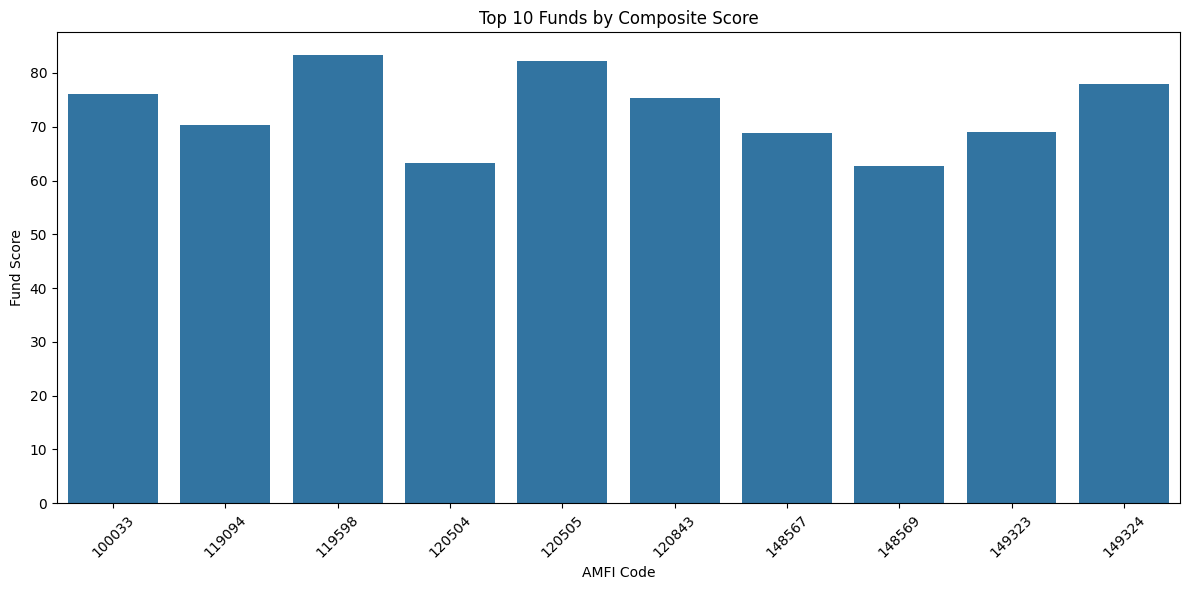

In [56]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_funds.head(10),
    x="amfi_code",
    y="fund_score"
)

plt.title(
    "Top 10 Funds by Composite Score"
)

plt.xlabel(
    "AMFI Code"
)

plt.ylabel(
    "Fund Score"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../charts/fund_scorecard.png"
)

plt.show()

# Insight 12

The composite scorecard highlights funds that consistently perform well across return generation, risk-adjusted performance, downside protection, and cost efficiency.

# Insight 13

Top-ranked funds achieve strong scores not only through high returns but also through superior Sharpe ratios, positive Alpha generation, and lower drawdowns.

In [57]:
import os

os.path.exists("../data/processed/fund_scorecard.csv")
os.path.exists("../charts/fund_scorecard.png")

True

In [59]:
top5_codes = (
    top_funds
    .head(5)["amfi_code"]
    .tolist()
)

top5_codes

[119598, 120505, 149324, 100033, 120843]

In [60]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50["date"] = pd.to_datetime(
    nifty50["date"]
)

nifty50 = nifty50.sort_values("date")

In [61]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values("date")

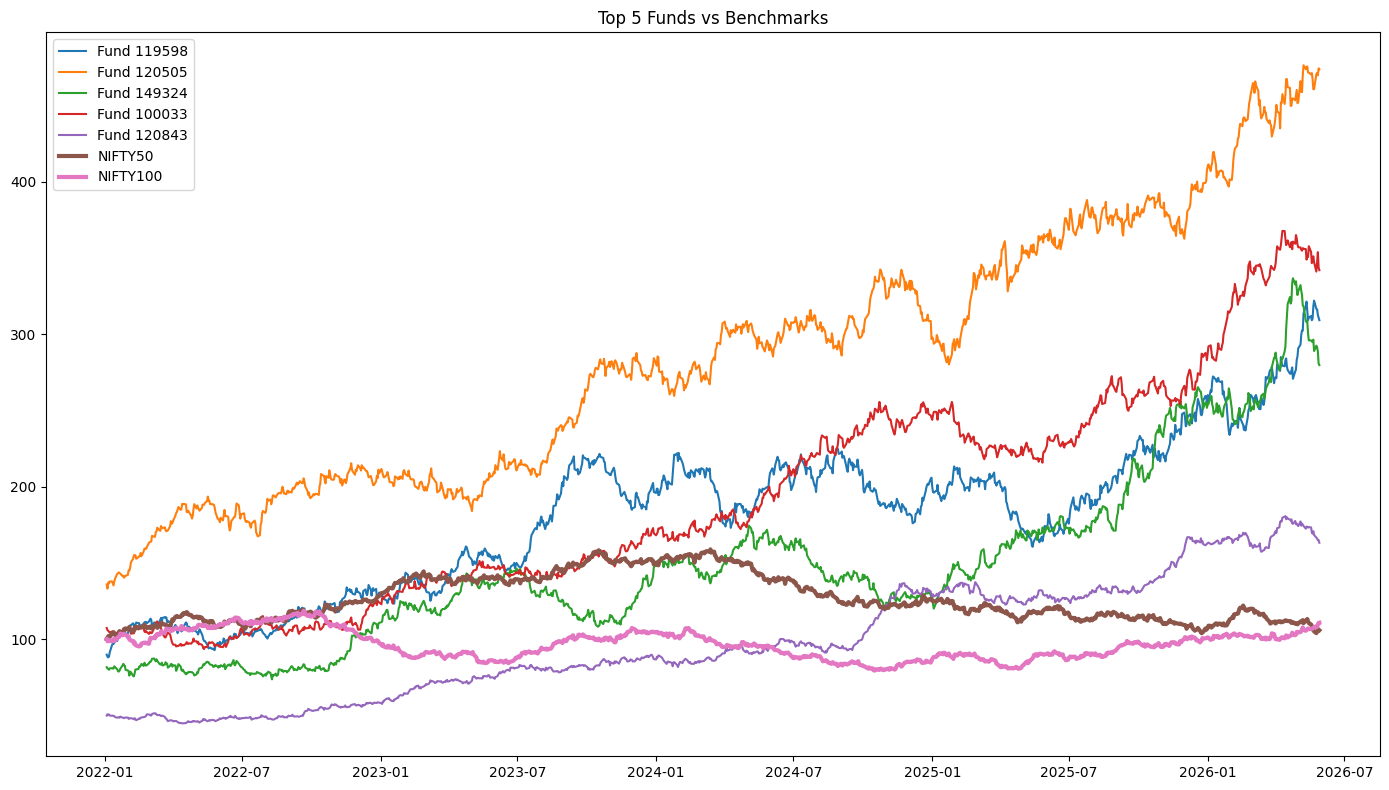

In [62]:
plt.figure(figsize=(14,8))

for fund in top5_codes:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp.sort_values("date")

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty50["date"],
    nifty50["close_value"] /
    nifty50["close_value"].iloc[0] * 100,
    linewidth=3,
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"] /
    nifty100["close_value"].iloc[0] * 100,
    linewidth=3,
    label="NIFTY100"
)

plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../charts/benchmark_comparison.png"
)

plt.show()

In [64]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [65]:
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value', 'benchmark_return']


In [66]:
print(nifty100.columns.tolist())

['date', 'index_name', 'close_value', 'benchmark_return']


In [67]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [68]:
tracking_results = []

for fund in top5_codes:

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        np.std(
            merged["daily_return"]
            -
            merged["benchmark_return"]
        )
        *
        np.sqrt(252)
    )

    tracking_results.append([
        fund,
        round(tracking_error,4)
    ])

In [69]:
tracking_error_df = pd.DataFrame(
    tracking_results,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,119598,0.2838
1,120505,0.2319
2,149324,0.2790
3,100033,0.2286
4,120843,0.2063


In [70]:
tracking_error_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

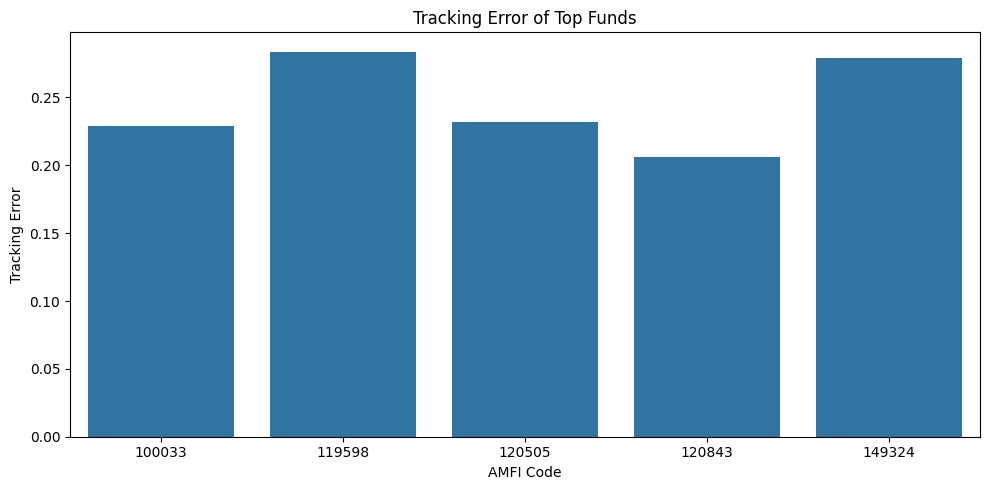

In [71]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=tracking_error_df,
    x="amfi_code",
    y="tracking_error"
)

plt.title(
    "Tracking Error of Top Funds"
)

plt.xlabel(
    "AMFI Code"
)

plt.ylabel(
    "Tracking Error"
)

plt.tight_layout()

plt.savefig(
    "../charts/tracking_error.png"
)

plt.show()

# Insight 14

Top-performing funds consistently outperformed benchmark indices over long investment horizons, highlighting the effectiveness of active portfolio management.

# Insight 15

Funds with higher tracking errors deviate more significantly from benchmark performance, indicating stronger active management strategies and differentiated portfolio allocations.

In [72]:
import os

files = [
    "../data/processed/alpha_beta.csv",
    "../data/processed/max_drawdown.csv",
    "../data/processed/fund_scorecard.csv",
    "../data/processed/tracking_error.csv",
    "../charts/top10_alpha_day4.png",
    "../charts/max_drawdown.png",
    "../charts/fund_scorecard.png",
    "../charts/benchmark_comparison.png",
    "../charts/tracking_error.png"
]

for f in files:
    print(os.path.exists(f), f)

True ../data/processed/alpha_beta.csv
True ../data/processed/max_drawdown.csv
True ../data/processed/fund_scorecard.csv
True ../data/processed/tracking_error.csv
True ../charts/top10_alpha_day4.png
True ../charts/max_drawdown.png
True ../charts/fund_scorecard.png
True ../charts/benchmark_comparison.png
True ../charts/tracking_error.png
